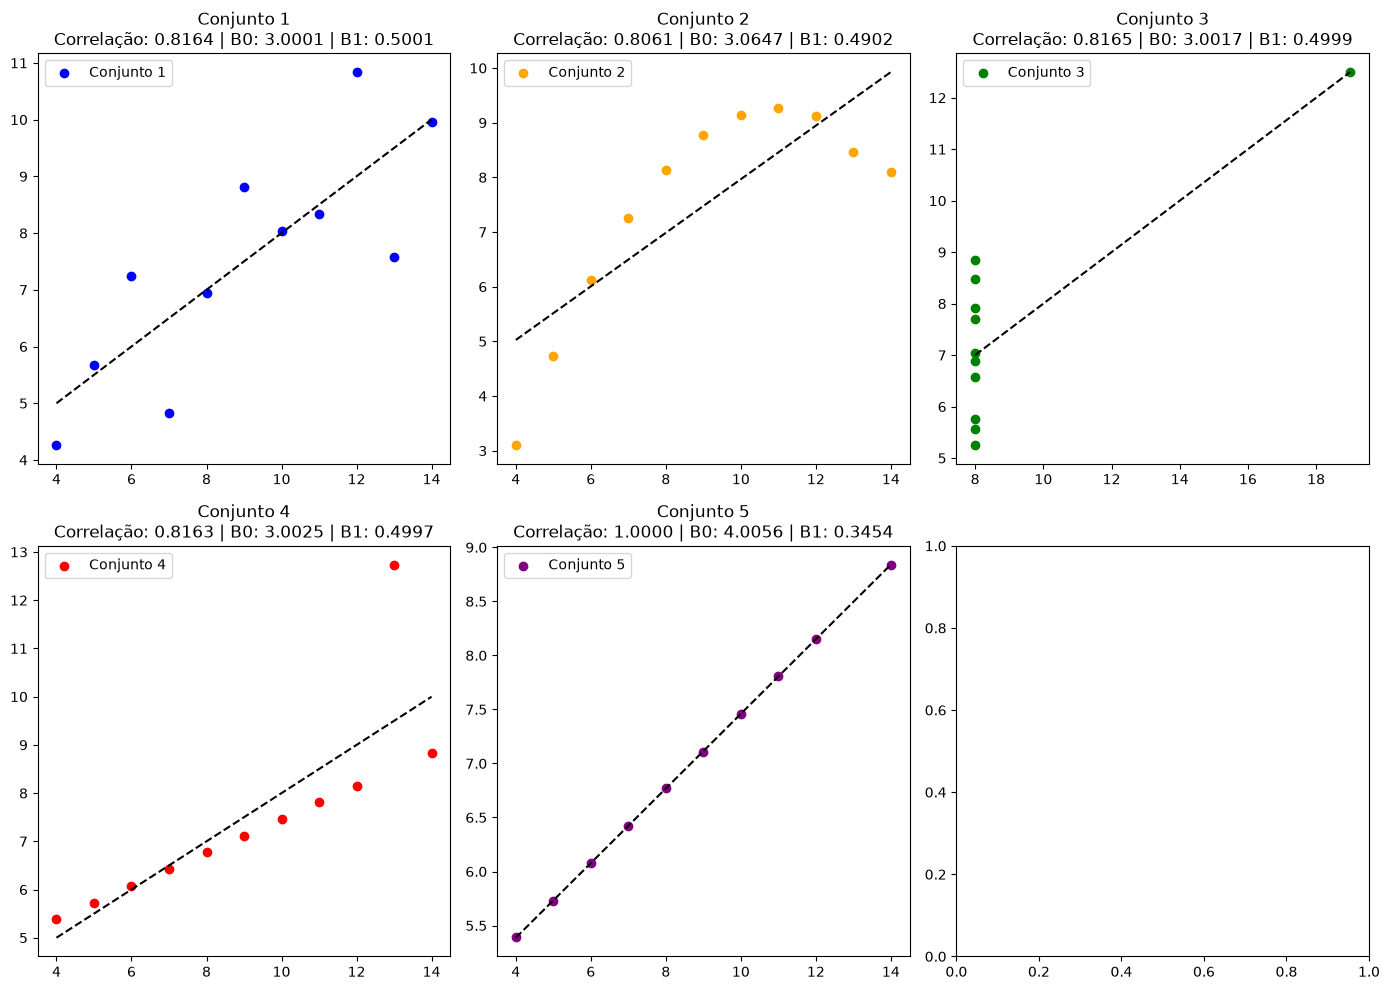

In [5]:
    import numpy as np
    import matplotlib.pyplot as plt

    # Dados fornecidos
    x1 = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
    y1 = [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]

    x2 = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
    y2 = [9.14, 8.14, 8.47, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]

    x3 = [8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 19]
    y3 = [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 5.56, 7.91, 6.89, 12.50]

    x4 = [10.0, 8.0, 13.0, 9.0, 11.0, 14.0, 6.0, 4.0, 12.0, 7.0, 5.0]
    y4 = [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]
    
    x5 = [10.0, 8.0, 9.0, 11.0, 14.0, 6.0, 4.0, 12.0, 7.0, 5.0]
    y5 = [7.46, 6.77, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]

    # Funções Matemáticas
    def correlacao_linear(x, y):
        n = len(x)
        sum_x = np.sum(x)
        sum_y = np.sum(y)
        sum_xy = np.sum(np.multiply(x, y))
        sum_x2 = np.sum(np.power(x, 2))
        sum_y2 = np.sum(np.power(y, 2))

        numerator = (n * sum_xy) - (sum_x * sum_y)
        denominator = np.sqrt((n * sum_x2 - sum_x ** 2) * (n * sum_y2 - sum_y ** 2))

        if denominator == 0:
            return 0
        else:
            return numerator / denominator

    def regressao_linear(x, y):
        n = len(x)
        sum_x = np.sum(x)
        sum_y = np.sum(y)
        sum_xy = np.sum(np.multiply(x, y))
        sum_x2 = np.sum(np.power(x, 2))

        slope = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
        intercept = (sum_y - slope * sum_x) / n

        return slope, intercept

    datasets = [
        (x1, y1, 'blue', 'Conjunto 1'),
        (x2, y2, 'orange', 'Conjunto 2'),
        (x3, y3, 'green', 'Conjunto 3'),
        (x4, y4, 'red', 'Conjunto 4'),
        (x5, y5, 'purple', 'Conjunto 5')
    ]

    # Criando a figura com 5 subgráficos (2 linhas, 3 colunas)
    fig, axs = plt.subplots(2, 3, figsize=(14, 10))

    # Transformando a matriz 2x3 de eixos em uma lista simples (0 a 4) para facilitar o laço
    axs = axs.flatten()

    for i, (x, y, color, label) in enumerate(datasets):
        x_arr = np.array(x)
        y_arr = np.array(y)
        
        r = correlacao_linear(x_arr, y_arr)
        
        b1, b0 = regressao_linear(x_arr, y_arr)
        
        y_previsto = b0 + b1 * x_arr
        
        axs[i].scatter(x_arr, y_arr, color=color, label=label)
        
        x_sorted = np.sort(x_arr)
        y_previsto_sorted = b0 + b1 * x_sorted
        axs[i].plot(x_sorted, y_previsto_sorted, color='black', linestyle='--')
        
        # 6. Adicionando os títulos com os resultados (arredondados para 4 casas decimais)
        title_str = f"{label}\nCorrelação: {r:.4f} | B0: {b0:.4f} | B1: {b1:.4f}"
        axs[i].set_title(title_str)
        axs[i].legend()

    plt.tight_layout()
    plt.show()
